# Spritpreisvorhersage – MLP Regression
**Predictive Analytics | HS Aalen | Semester 1**

Dieses Notebook folgt dem **CRISP-DM Prozessmodell** (Cross Industry Standard Process for Data Mining):

| Phase | Abschnitt |
|---|---|
| 1 – Business Understanding | §1 |
| 2 – Data Understanding | §2 |
| 3 – Data Preparation | §3 |
| 4 – Modeling | §4 |
| 5 – Evaluation | §5 |
| 6 – Deployment (vereinfacht) | §6 |

---
## §0 – Setup & Konfiguration

Alle Importe und Pfade werden hier zentral definiert.  
Dadurch ist das Notebook portabel: nur `DATA_RAW` muss ggf. angepasst werden.

### Voraussetzungen
```
pip install pandas numpy matplotlib seaborn scikit-learn pyarrow
```

In [3]:
# ── Standardbibliotheken ──────────────────────────────────────────────────────
import os
import glob
import warnings
from pathlib import Path

# ── Numerik & Daten ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisierung ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── Scikit-learn: Preprocessing ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── Scikit-learn: Modelle ─────────────────────────────────────────────────────
from sklearn.neural_network import MLPRegressor
from sklearn.dummy import DummyRegressor

# ── Scikit-learn: Validierung & Metriken ─────────────────────────────────────
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Warnungen unterdrücken (Konvergenzhinweise während Exploration) ───────────
warnings.filterwarnings('ignore', category=UserWarning)

# ── Einheitliches Plot-Styling ────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 4)})

print('Importe erfolgreich.')

Importe erfolgreich.


In [4]:
# ── Pfadkonfiguration ─────────────────────────────────────────────────────────
#
# DATA_RAW     : Wurzel des tankerkoenig-data Repos
# DATA_PROC    : Ausgabeverzeichnis für verarbeitete Daten (Parquet-Cache)
# PARQUET_PATH : Pfad der aggregierten stündlichen Nationaldaten
#
# Passe DATA_RAW an, falls das Repo an einem anderen Ort liegt.

DATA_RAW   = Path('../tankerkoenig-data/prices')
DATA_PROC  = Path('data/processed')
DATA_PROC.mkdir(parents=True, exist_ok=True)

PARQUET_PATH = DATA_PROC / 'hourly_national_diesel.parquet'

# ── Zeitliche Split-Grenzen (CRISP-DM: Train / Val / Test) ───────────────────
#
# Train      : 2014-06 – 2021-12  (Modelllernen)
# Validation : 2022-01 – 2023-12  (Hyperparameter-Tuning)
# Test       : 2024-01 – 2026-05  (finale, unberührte Bewertung)
#
TRAIN_END = '2021-12-31 23:00:00+01:00'
VAL_END   = '2023-12-31 23:00:00+01:00'

print(f'Rohdaten-Pfad  : {DATA_RAW.resolve()}')
print(f'Verarbeitungs- : {DATA_PROC.resolve()}')
print(f'Parquet-Cache  : {PARQUET_PATH.resolve()}')

Rohdaten-Pfad  : /home/jawasch/Documents/HS_Aalen/Sem1/PredictiveAnalytics/Projekt/tankerkoenig-data/prices
Verarbeitungs- : /home/jawasch/Documents/HS_Aalen/Sem1/PredictiveAnalytics/Projekt/data_analysis/data/processed
Parquet-Cache  : /home/jawasch/Documents/HS_Aalen/Sem1/PredictiveAnalytics/Projekt/data_analysis/data/processed/hourly_national_diesel.parquet


---
## §1 – Business Understanding

### Ausgangssituation

Ein Spediteur betreibt eine Flotte von **25 LKWs**.  
Durchschnittliche Kennzahlen laut Aufgabenstellung:

| Kennzahl | Wert |
|---|---|
| Verbrauch je LKW | 30 L / 100 km |
| Fahrleistung je LKW | 500 km / Tag |
| **Tagesverbrauch Flotte** | **3 750 L Diesel** |

### Wirtschaftliche Relevanz

Bei einem mittleren Dieselpreis von 1,70 €/L und einer Preisschwankung von nur **1 Cent/L**  
entstehen bereits **37,50 € Tageskosten-Differenz** (3 750 L × 0,01 €).  
Schwankungen von 5–10 Cent führen so zu **187–375 € täglich**.

### Zieldefinition

> **Vorhersage des stündlichen nationalen Mitteldieselpreises für einen Zeithorizont von 48 Stunden.**  
> Innerhalb dieses Fensters wird das **lokale Preisminimum** identifiziert –  
> das ist der optimale Zeitpunkt für den Tankvorgang.

### Modellierungsansatz

- **Algorithmus**: `MLPRegressor` (scikit-learn) – erlaubt nichtlineare Zusammenhänge
- **Validierung**: `TimeSeriesSplit` – respektiert die zeitliche Ordnung der Daten
- **Features**: Lag-Features, Rolling-Mittelwerte, Kalender-Merkmale
- **Zielvariable**: `diesel_mean` – stündlicher Mittelpreis aller deutschen Tankstellen in €/L

### Abgrenzung

- Phase 1 (dieses Notebook): ausschließlich Preis-Historie als Input
- Phase 2 (Folge-Notebook): Erweiterung um externe Variable Rohölpreis (Brent)

---
## §2 – Data Understanding

### Datenquelle

**Tankerkönig** stellt unter Creative-Commons-Lizenz (BY-NC-SA 4.0) historische Kraftstoffpreisdaten  
aller deutschen Tankstellen bereit. Dateistruktur:

```
tankerkoenig-data/
└── prices/
    └── YYYY/
        └── MM/
            └── YYYY-MM-DD-prices.csv
```

Jede CSV enthält **Preisänderungs-Events** je Tankstelle (kein festes Raster).  
Für die Modellierung aggregieren wir diese zu einem **stündlichen Nationalpreis**.

### Datenschema

| Spalte | Typ | Beschreibung |
|---|---|---|
| `date` | datetime+tz | Zeitstempel der Preisänderung (Europe/Berlin) |
| `station_uuid` | str | UUID der Tankstelle |
| `diesel` | float | Dieselpreis in €/L (0 = nicht gemeldet) |
| `e5` | float | Super E5 Preis in €/L |
| `e10` | float | Super E10 Preis in €/L |
| `dieselchange` | int | 0=gleich, 1=geändert, 2=entfernt, 3=neu |
| `e5change` | int | wie dieselchange |
| `e10change` | int | wie dieselchange |

In [5]:
# ── §2.1 Schemainspektionmit einer Beispieldatei ──────────────────────────────
#
# Wir laden eine einzelne CSV, um Datentypen, Wertebereich und
# Missings schnell zu überblicken – ohne alle 4 365 Dateien zu lesen.

sample_files = sorted(glob.glob(str(DATA_RAW / '2024/01/*.csv')))
assert sample_files, 'Keine Beispieldatei gefunden – DATA_RAW korrekt gesetzt?'

sample = pd.read_csv(
    sample_files[0],
    parse_dates=['date'],
    low_memory=False
)

print(f'Datei        : {Path(sample_files[0]).name}')
print(f'Zeilen       : {len(sample):,}')
print(f'Spalten      : {list(sample.columns)}')
print()
print('Datentypen:')
print(sample.dtypes)
print()
print('Fehlende Werte (absolut):')
print(sample.isnull().sum())

Datei        : 2024-01-01-prices.csv
Zeilen       : 327,799
Spalten      : ['date', 'station_uuid', 'diesel', 'e5', 'e10', 'dieselchange', 'e5change', 'e10change']

Datentypen:
date            datetime64[ns, UTC+01:00]
station_uuid                       object
diesel                            float64
e5                                float64
e10                               float64
dieselchange                        int64
e5change                            int64
e10change                           int64
dtype: object

Fehlende Werte (absolut):
date            0
station_uuid    0
diesel          0
e5              0
e10             0
dieselchange    0
e5change        0
e10change       0
dtype: int64


In [6]:
# ── §2.1 (Forts.) Erste Zeilen & Wertebereich Diesel ─────────────────────────

print('Erste 5 Zeilen:')
display(sample.head())

print('\nDiesel-Preisstatistik (inkl. Nullwerte):')
print(sample['diesel'].describe())

# Wie viele Einträge haben einen gültigen (> 0) Dieselpreis?
valid_diesel = sample[sample['diesel'] > 0]
print(f'\nGültige Dieselpreise: {len(valid_diesel):,} / {len(sample):,}')
print(f'Change-Codes diesel  : {sample["dieselchange"].value_counts().to_dict()}')

Erste 5 Zeilen:


,date,station_uuid,diesel,e5,e10,dieselchange,e5change,e10change
0,2024-01-01 00:00:19+01:00,bba11e4c-d711-4e59-a84a-d0c660a416b8,1.729,1.799,1.739,1,1,1
1,2024-01-01 00:00:19+01:00,1ca2cd6c-c5f7-43fb-87ba-84064faf7e42,1.659,1.739,1.679,0,1,1
2,2024-01-01 00:01:20+01:00,7a648916-974a-40d6-a6f5-7db1ce382564,1.659,1.729,1.669,1,1,1
3,2024-01-01 00:01:20+01:00,a9777311-b4b8-4201-bccd-dfc6ae4a9557,1.679,1.779,1.729,1,1,1
4,2024-01-01 00:01:20+01:00,6e6481ca-530c-4cfd-b5cf-2250c71c7d56,1.669,1.769,1.709,0,1,1



Diesel-Preisstatistik (inkl. Nullwerte):
count    327799.000000
mean          1.688063
std           0.060193
min          -0.001000
25%           1.649000
50%           1.679000
75%           1.719000
max           4.488000
Name: diesel, dtype: float64

Gültige Dieselpreise: 327,740 / 327,799
Change-Codes diesel  : {1: 260690, 0: 67081, 2: 16, 3: 12}


In [7]:
# ── §2.2 Vollständige Datenaggregation → Parquet-Cache ───────────────────────
#
# Strategie:  Für jede der ~4 365 Tages-CSVs:
#   1. Nur Spalten 'date' + 'diesel' einlesen
#   2. Ungültige Preise (diesel <= 0 oder > 4.0) entfernen
#   3. Auf volle Stunde abrunden (floor)
#   4. Stündlichen Mittelwert berechnen
#   5. Nur diesen Mini-DataFrame akkumulieren
#
# Ergebnis: statt 89 GB Rohdaten nur ~87 000 Zeilen im Parquet-Cache.
#
# Falls der Cache bereits existiert, wird dieser Schritt übersprungen.

if PARQUET_PATH.exists():
    print(f'Cache gefunden – überspringe Aggregation: {PARQUET_PATH}')
else:
    print('Starte Aggregation aller Preis-CSVs …')
    print('(Das dauert beim ersten Mal mehrere Minuten – bitte warten)')
    print()

    all_files = sorted(glob.glob(str(DATA_RAW / '**/*.csv'), recursive=True))
    print(f'Gefundene Dateien: {len(all_files):,}')

    chunks = []
    errors = []

    for i, fp in enumerate(all_files):
        try:
            df = pd.read_csv(
                fp,
                usecols=['date', 'diesel'],  # nur benötigte Spalten laden
                parse_dates=['date'],
                low_memory=False
            )
            # Ungültige Preise entfernen
            df = df[(df['diesel'] > 0.5) & (df['diesel'] < 4.0)]
            if df.empty:
                continue

            # Auf Stunde runden und Mittelwert berechnen
            df['date'] = df['date'].dt.floor('h')
            hourly = df.groupby('date')['diesel'].mean().reset_index()
            chunks.append(hourly)

        except Exception as e:
            errors.append((fp, str(e)))

        if (i + 1) % 500 == 0:
            print(f'  {i+1:,} / {len(all_files):,} Dateien verarbeitet …')

    print(f'Aggregation abgeschlossen. Fehler: {len(errors)}')

    # Zusammenführen und nach Datum sortieren
    df_all = pd.concat(chunks, ignore_index=True)
    df_all = df_all.groupby('date')['diesel'].mean().reset_index()
    df_all.sort_values('date', inplace=True)
    df_all.reset_index(drop=True, inplace=True)

    # Parquet speichern (komprimiert, schnelles Wiedereinlesen)
    df_all.to_parquet(PARQUET_PATH, index=False)
    print(f'Parquet gespeichert: {PARQUET_PATH} ({PARQUET_PATH.stat().st_size / 1024:.0f} KB)')
    print(f'Gesamt-Zeilen: {len(df_all):,}')

Cache gefunden – überspringe Aggregation: data/processed/hourly_national_diesel.parquet


In [8]:
# ── §2.2 (Forts.) Cache einlesen & ersten Überblick ──────────────────────────

df = pd.read_parquet(PARQUET_PATH)
df['date'] = pd.to_datetime(df['date'], utc=True).dt.tz_convert('Europe/Berlin')
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

print('=== Stündlicher nationaler Diesel-Mittelpreis ===')
print(f'Zeitraum : {df.index.min()} → {df.index.max()}')
print(f'Zeilen   : {len(df):,}')
print()
print(df.describe())

=== Stündlicher nationaler Diesel-Mittelpreis ===
Zeitraum : 2014-06-08 09:00:00+02:00 → 2026-05-20 23:00:00+02:00
Zeilen   : 104,030

              diesel
count  104030.000000
mean        1.414907
std         0.296397
min         0.912779
25%         1.181920
50%         1.314314
75%         1.630866
max         2.502495


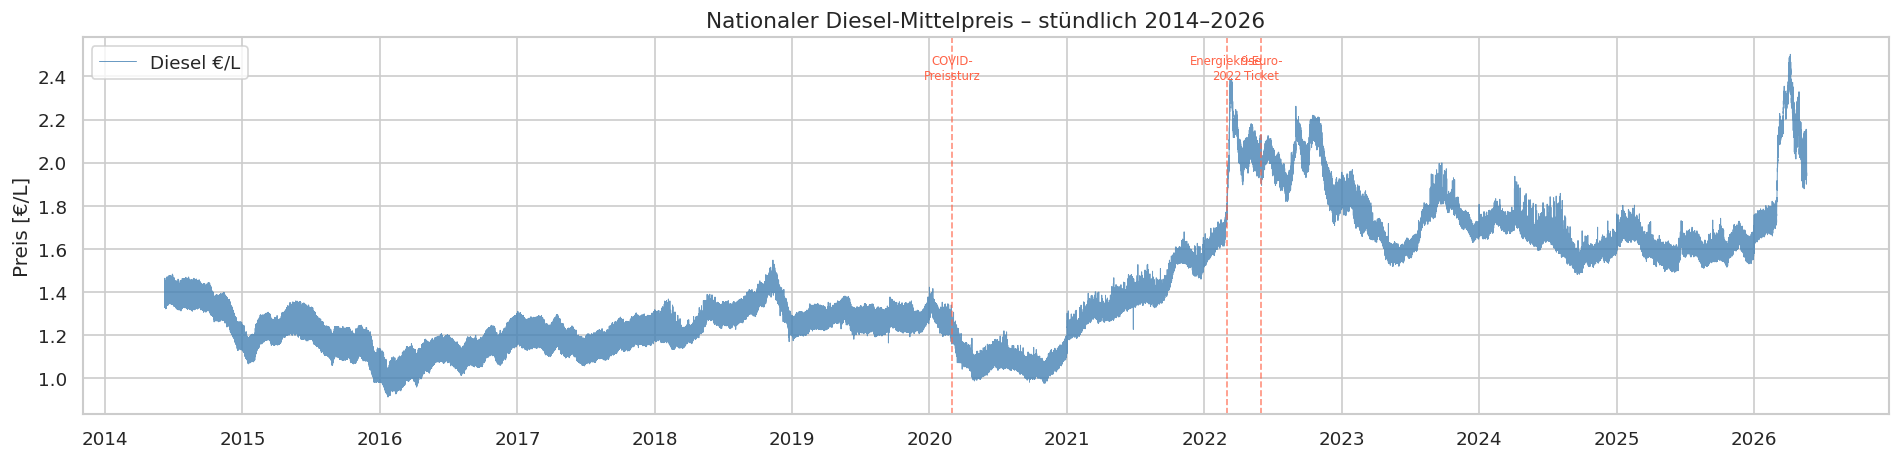

In [7]:
# ── §2.3 EDA – Gesamte Zeitreihe (2014–2026) ──────────────────────────────────
#
# Ziel: Preisstruktur, Trends und große Ereignisse (COVID, Energiekrise 2022)
# sichtbar machen.

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df.index, df['diesel'], lw=0.6, color='steelblue', alpha=0.8, label='Diesel €/L')
ax.set_title('Nationaler Diesel-Mittelpreis – stündlich 2014–2026', fontsize=13)
ax.set_ylabel('Preis [€/L]')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

# Annotierung wichtiger Ereignisse
events = {
    '2020-03': 'COVID-\nPreissturz',
    '2022-03': 'Energiekrise\n2022',
    '2022-06': '9-Euro-\nTicket'
}
for date_str, label in events.items():
    ax.axvline(pd.Timestamp(date_str, tz='Europe/Berlin'), color='tomato', lw=1, ls='--', alpha=0.7)
    ax.text(pd.Timestamp(date_str, tz='Europe/Berlin'), ax.get_ylim()[1] * 0.97,
            label, fontsize=7, color='tomato', ha='center', va='top')

ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_4856/1230410936.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='Jahr', y='diesel', ax=ax, palette='Blues_d', fliersize=1)


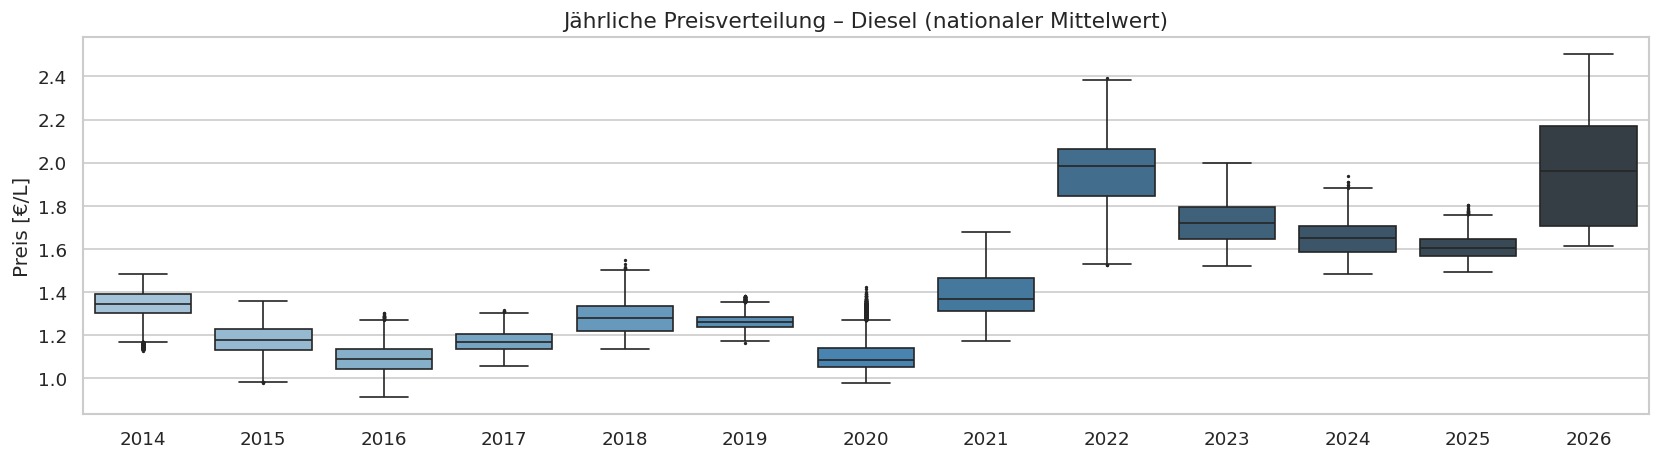

In [9]:
# ── §2.3 EDA – Jahresvergleich als Boxplot ────────────────────────────────────
#
# Zeigt die jährliche Preisverteilung und macht Ausreißerjahre sichtbar.

df_box = df.copy()
df_box['Jahr'] = df_box.index.year

fig, ax = plt.subplots(figsize=(14, 4))
sns.boxplot(data=df_box, x='Jahr', y='diesel', ax=ax, palette='Blues_d', fliersize=1)
ax.set_title('Jährliche Preisverteilung – Diesel (nationaler Mittelwert)', fontsize=13)
ax.set_ylabel('Preis [€/L]')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

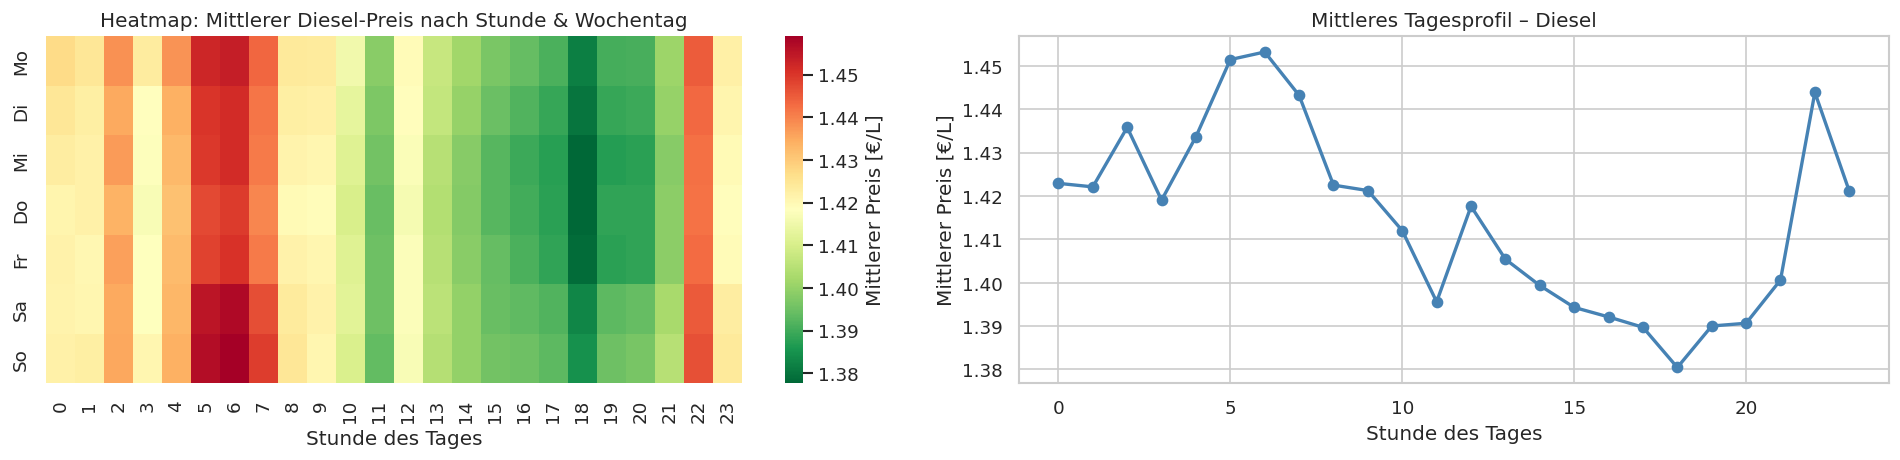

In [10]:
# ── §2.3 EDA – Saisonalität: Stunde des Tages & Wochentag ────────────────────
#
# Tankpreise folgen bekannten Mustern: morgens höher, abends günstiger.
# Diese Muster begründen unsere Kalender-Features in §3.

df_season = df.copy()
df_season['Stunde']   = df_season.index.hour
df_season['Wochentag'] = df_season.index.dayofweek  # 0=Mo, 6=So

pivot_heatmap = df_season.groupby(['Wochentag', 'Stunde'])['diesel'].mean().unstack()
wochentage = ['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']
pivot_heatmap.index = wochentage

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Heatmap: Stunde × Wochentag
sns.heatmap(
    pivot_heatmap, ax=axes[0], cmap='RdYlGn_r',
    cbar_kws={'label': 'Mittlerer Preis [€/L]'}
)
axes[0].set_title('Heatmap: Mittlerer Diesel-Preis nach Stunde & Wochentag')
axes[0].set_xlabel('Stunde des Tages')

# Tagesmuster als Linienchart
df_season.groupby('Stunde')['diesel'].mean().plot(
    ax=axes[1], marker='o', lw=2, color='steelblue'
)
axes[1].set_title('Mittleres Tagesprofil – Diesel')
axes[1].set_xlabel('Stunde des Tages')
axes[1].set_ylabel('Mittlerer Preis [€/L]')

plt.tight_layout()
plt.show()

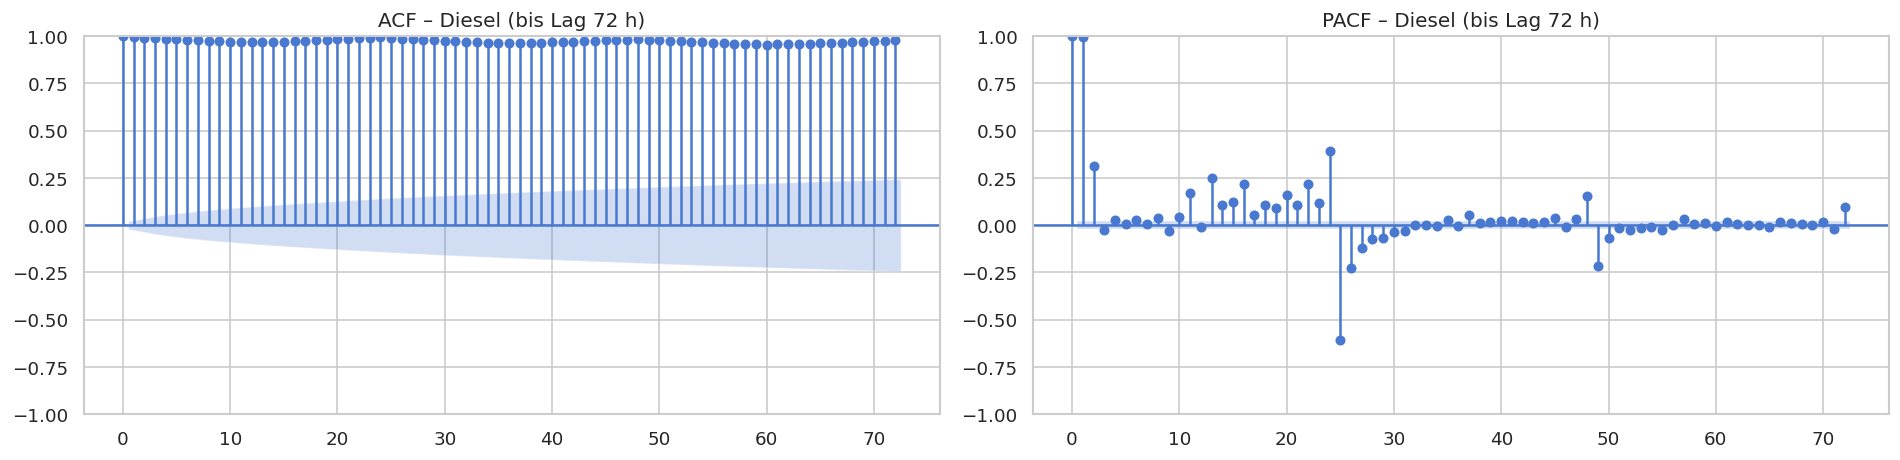

Interpretation:
  Lag 1  : Stärkste direkte Autokorrelation – Preis der letzten Stunde
  Lag 3  : Relevanter Kurzfrist-Lag
  Lag 24 : Tageszyklus – Preis gestern zur selben Zeit


In [11]:
# ── §2.3 EDA – ACF & PACF (Autokorrelationsanalyse) ──────────────────────────
#
# ACF  (Autocorrelation Function): zeigt, wie stark der Preis mit seinen
#      vergangenen Werten korreliert → begründet Lag-Feature-Auswahl
# PACF (Partial ACF): direkter Effekt jedes Lags nach Herausrechnen
#      der zwischenliegenden Lags
#
# Erwartung:
# - Lag 1 h : sehr hohe Korrelation (Preis ändert sich selten)
# - Lag 24 h: Korrelation durch Tagesmuster
# - Lag 168 h (1 Woche): schwächere Wochensaisonalität

# Letztes Jahr für ACF verwenden (vollständige, dichte Zeitreihe)
df_acf = df['diesel'].dropna().iloc[-8760:]  # ~1 Jahr

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_acf, lags=72, ax=axes[0], title='ACF – Diesel (bis Lag 72 h)')
plot_pacf(df_acf, lags=72, ax=axes[1], title='PACF – Diesel (bis Lag 72 h)', method='ywm')
plt.tight_layout()
plt.show()
print('Interpretation:')
print('  Lag 1  : Stärkste direkte Autokorrelation – Preis der letzten Stunde')
print('  Lag 3  : Relevanter Kurzfrist-Lag')
print('  Lag 24 : Tageszyklus – Preis gestern zur selben Zeit')

---
## §3 – Data Preparation

### Ziel
Aus der rohen Zeitreihe einen ML-fähigen Feature-Matrix erstellen.  
Alle Schritte folgen dem Prinzip **kein Datenleck** – Skalierung und Statistiken
werden ausschließlich auf den Trainingsdaten berechnet.

### Geplante Features

| Feature | Beschreibung | Motivation (ACF) |
|---|---|---|
| `lag_1h` | Preis vor 1 Stunde | Lag-1 dominanter ACF-Peak |
| `lag_3h` | Preis vor 3 Stunden | Kurzfristige Trend-Info |
| `lag_24h` | Preis vor 24 Stunden | Tageszyklus |
| `roll_mean_6h` | Gleit. Mittel 6 Stunden | Glätten von Ausreißern |
| `roll_mean_24h` | Gleit. Mittel 24 Stunden | Tageszyklus-Baseline |
| `hour_of_day` | Stunde 0–23 | Intraday-Saisonalität |
| `day_of_week` | 0=Mo … 6=So | Wochensaisonalität |

In [13]:
# ── §3.1 Vollständiger Stundenraster sicherstellen ────────────────────────────
#
# Die Rohdaten können einzelne Stunden fehlen (keine Preisänderungen).
# Wir erzwingen einen lückenlosen stündlichen Index und füllen Lücken
# mit dem vorherigen bekannten Wert (Forward Fill = letzter gültiger Preis).
#
# Hintergrund: Bei Tankstellen bleibt ein unveränderter Preis gültig,
# bis die nächste Änderung gemeldet wird – Forward Fill ist semantisch korrekt.

full_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='h',
    tz='Europe/Berlin'
)

df_full = df.reindex(full_index)
missing_before = df_full['diesel'].isna().sum()
df_full['diesel'] = df_full['diesel'].ffill()
missing_after = df_full['diesel'].isna().sum()

print(f'Gesamtstunden im Index : {len(df_full):,}')
print(f'Fehlende Stunden vorher: {missing_before:,} ({missing_before/len(df_full)*100:.2f} %)')
print(f'Fehlende Stunden danach: {missing_after:,}  (verbleibende NaN am Anfang sind OK)')

Gesamtstunden im Index : 104,751
Fehlende Stunden vorher: 721 (0.69 %)
Fehlende Stunden danach: 0  (verbleibende NaN am Anfang sind OK)


In [14]:
# ── §3.2 Feature Engineering ──────────────────────────────────────────────────
#
# Alle Features werden auf dem vollständigen DataFrame berechnet.
# Dadurch entstehen NaN-Zeilen am Anfang (z.B. für lag_24h die ersten 24 h).
# Diese werden in §3.3 entfernt.

df_feat = df_full.copy()

# Lag-Features: Preis zu früheren Zeitpunkten (shift = positive Anzahl = Vergangenheit)
df_feat['lag_1h']  = df_feat['diesel'].shift(1)
df_feat['lag_3h']  = df_feat['diesel'].shift(3)
df_feat['lag_24h'] = df_feat['diesel'].shift(24)

# Rolling-Features: Gleitende Mittelwerte (min_periods=1 um Randeffekte zu minimieren)
df_feat['roll_mean_6h']  = df_feat['diesel'].shift(1).rolling(6,  min_periods=1).mean()
df_feat['roll_mean_24h'] = df_feat['diesel'].shift(1).rolling(24, min_periods=1).mean()

# Kalender-Features: zyklische Zeitinformation
df_feat['hour_of_day']  = df_feat.index.hour
df_feat['day_of_week']  = df_feat.index.dayofweek  # 0 = Montag

# Liste der Feature-Spalten (für späteren Zugriff)
FEATURE_COLS = ['lag_1h', 'lag_3h', 'lag_24h',
                'roll_mean_6h', 'roll_mean_24h',
                'hour_of_day', 'day_of_week']
TARGET_COL = 'diesel'

print('Erstellte Features:')
for col in FEATURE_COLS:
    print(f'  {col:<20} NaN: {df_feat[col].isna().sum():,}')

Erstellte Features:
  lag_1h               NaN: 1
  lag_3h               NaN: 3
  lag_24h              NaN: 24
  roll_mean_6h         NaN: 1
  roll_mean_24h        NaN: 1
  hour_of_day          NaN: 0
  day_of_week          NaN: 0


In [15]:
# ── §3.3 NaN-Zeilen entfernen ─────────────────────────────────────────────────
#
# Die ersten 24 Stunden enthalten NaN-Lags und werden entfernt.
# Da der Datensatz über 10 Jahre geht, ist dieser Verlust vernachlässigbar.

df_feat.dropna(subset=FEATURE_COLS + [TARGET_COL], inplace=True)

print(f'Verbleibende Zeilen nach NaN-Drop: {len(df_feat):,}')
print(f'Erster Eintrag : {df_feat.index.min()}')
print(f'Letzter Eintrag: {df_feat.index.max()}')

Verbleibende Zeilen nach NaN-Drop: 104,727
Erster Eintrag : 2014-06-09 09:00:00+02:00
Letzter Eintrag: 2026-05-20 23:00:00+02:00


In [16]:
# ── §3.4 Temporaler Train / Validation / Test Split ───────────────────────────
#
# CRISP-DM schreibt vor, Modell-Bewertung auf unberührten Daten durchzuführen.
# Da es sich um eine Zeitreihe handelt, KEIN zufälliges Mischen:
#
#   Train      : 2014-06 → 2021-12  (Modell lernt historische Muster)
#   Validation : 2022-01 → 2023-12  (Hyperparameter werden hier bewertet)
#   Test       : 2024-01 → 2026-05  (finale Bewertung, einmalig am Ende)
#
# Wichtig: Der Test-Split wird erst in §5 geöffnet!

train_end_ts = pd.Timestamp(TRAIN_END).tz_convert('Europe/Berlin')
val_end_ts   = pd.Timestamp(VAL_END).tz_convert('Europe/Berlin')

mask_train = df_feat.index <= train_end_ts
mask_val   = (df_feat.index > train_end_ts) & (df_feat.index <= val_end_ts)
mask_test  = df_feat.index > val_end_ts

df_train = df_feat[mask_train]
df_val   = df_feat[mask_val]
df_test  = df_feat[mask_test]

print('=== Datensatz-Aufteilung ===')
for name, split in [('Train', df_train), ('Validation', df_val), ('Test', df_test)]:
    print(f'{name:<12}: {len(split):>7,} Zeilen | {split.index.min().date()} → {split.index.max().date()}')

total = len(df_feat)
print(f'\nAnteile: Train {len(df_train)/total*100:.1f}% | '
      f'Val {len(df_val)/total*100:.1f}% | '
      f'Test {len(df_test)/total*100:.1f}%')

=== Datensatz-Aufteilung ===
Train       :  66,304 Zeilen | 2014-06-09 → 2021-12-31
Validation  :  17,520 Zeilen | 2022-01-01 → 2023-12-31
Test        :  20,903 Zeilen | 2024-01-01 → 2026-05-20

Anteile: Train 63.3% | Val 16.7% | Test 20.0%


In [18]:
# ── §3.5 Feature-Matrix & Zielvariable vorbereiten ────────────────────────────
#
# StandardScaler wird NUR auf Trainingsdaten gefittet (fit_transform).
# Auf Val und Test wird nur transform angewendet – kein Datenleck!

X_train = df_train[FEATURE_COLS].values
y_train = df_train[TARGET_COL].values

X_val   = df_val[FEATURE_COLS].values
y_val   = df_val[TARGET_COL].values

X_test  = df_test[FEATURE_COLS].values
y_test  = df_test[TARGET_COL].values

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform auf Train
X_val_sc   = scaler.transform(X_val)          # nur transform auf Val
X_test_sc  = scaler.transform(X_test)         # nur transform auf Test

print('Skalierung abgeschlossen.')
print(f'X_train_sc shape: {X_train_sc.shape}')
print(f'X_val_sc   shape: {X_val_sc.shape}')
print(f'X_test_sc  shape: {X_test_sc.shape}')
print(f'\nScaler Mittelwerte (Train): {scaler.mean_.round(4)}')

Skalierung abgeschlossen.
X_train_sc shape: (66304, 7)
X_val_sc   shape: (17520, 7)
X_test_sc  shape: (20903, 7)

Scaler Mittelwerte (Train): [ 1.2211  1.2211  1.221   1.2211  1.2211 11.5009  2.9986]


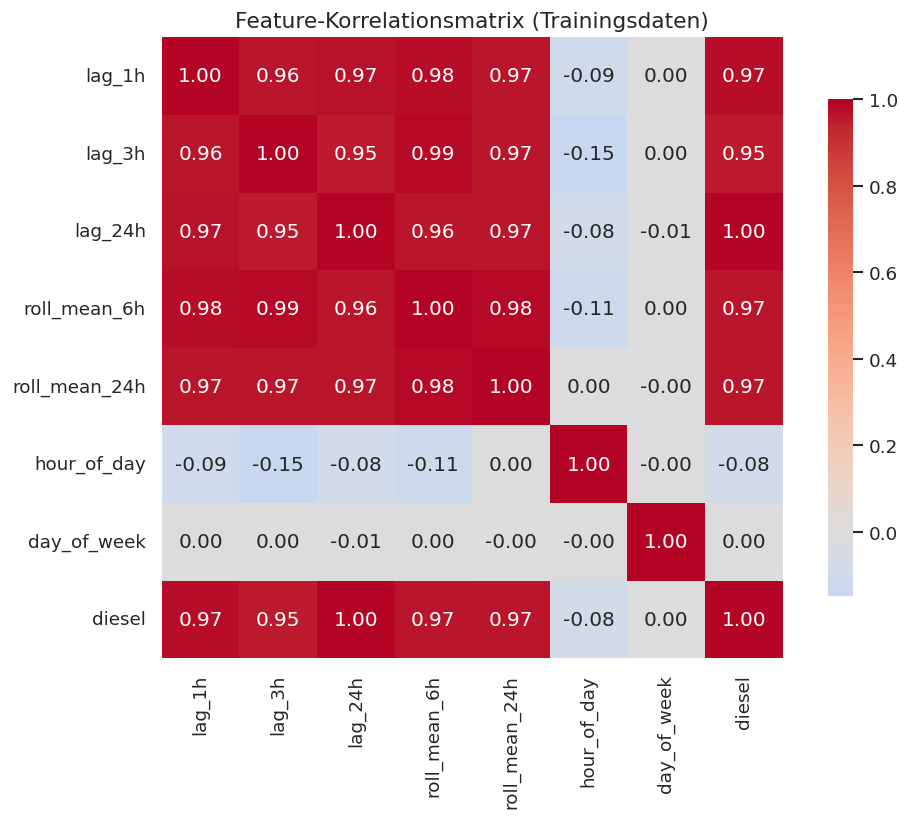

Korrelation mit Zielvariable diesel:
diesel           1.000000
lag_24h          0.995666
lag_1h           0.974627
roll_mean_6h     0.965738
roll_mean_24h    0.965316
lag_3h           0.951866
day_of_week      0.004720
hour_of_day     -0.078488


In [19]:
# ── §3.6 Feature-Korrelationsmatrix ──────────────────────────────────────────
#
# Prüft, ob Features untereinander stark korrelieren (Redundanz)
# und wie stark sie mit der Zielvariable korrelieren.

corr_cols = FEATURE_COLS + [TARGET_COL]
corr_matrix = df_train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature-Korrelationsmatrix (Trainingsdaten)', fontsize=13)
plt.tight_layout()
plt.show()

print('Korrelation mit Zielvariable diesel:')
print(corr_matrix['diesel'].sort_values(ascending=False).to_string())

---
## §4 – Modeling

### Vorgehen

1. **Baseline** mit `DummyRegressor` – untere Schranke, die unser Modell schlagen muss
2. **TimeSeriesSplit CV** auf Trainingsdaten – zeitkorrekte Kreuzvalidierung
3. **Validation-Set Bewertung** – Generalisierung vor dem Testset prüfen
4. **Finale Modelltraining** auf Train + Validation (Testset bleibt versiegelt)

### MLPRegressor Konfiguration

| Parameter | Wert | Begründung |
|---|---|---|
| `hidden_layer_sizes` | (128, 64) | 2-Layer: genug Kapazität für Nichtlinearität |
| `activation` | relu | Standard für Regression, vermeidet Vanishing Gradient |
| `solver` | adam | Adaptiver Optimizer, gut für nichtkonvexe Probleme |
| `max_iter` | 500 | Ausreichend für Konvergenz |
| `early_stopping` | True | Verhindert Überanpassung an Trainingsdaten |
| `validation_fraction` | 0.1 | 10 % der Trainingsdaten als interne Val. |
| `random_state` | 42 | Reproduzierbarkeit |

In [20]:
# ── §4.1 Baseline: DummyRegressor ─────────────────────────────────────────────
#
# Der DummyRegressor sagt immer den Mittelwert der Trainingsdaten vorher.
# Dies ist die triviale Untergrenze – jedes sinnvolle Modell muss besser sein.

baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train_sc, y_train)

y_val_baseline = baseline.predict(X_val_sc)

mae_baseline  = mean_absolute_error(y_val, y_val_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_val, y_val_baseline))
r2_baseline   = r2_score(y_val, y_val_baseline)

print('=== Baseline: DummyRegressor (mean) ===')
print(f'MAE  : {mae_baseline:.5f} €/L  ({mae_baseline*100:.3f} Cent/L)')
print(f'RMSE : {rmse_baseline:.5f} €/L')
print(f'R²   : {r2_baseline:.4f}')
print(f'Flotte (3750 L): MAE-Differenz = {mae_baseline * 3750:.2f} €/Tag')

=== Baseline: DummyRegressor (mean) ===
MAE  : 0.61158 €/L  (61.158 Cent/L)
RMSE : 0.63786 €/L
R²   : -11.3893
Flotte (3750 L): MAE-Differenz = 2293.41 €/Tag


In [21]:
# ── §4.2 TimeSeriesSplit Kreuzvalidierung (auf Trainingsdaten) ────────────────
#
# TimeSeriesSplit teilt die Trainingsdaten in n_splits Folds auf.
# Jeder Fold hat einen älteren Trainings- und einen neueren Validierungsbereich.
# → kein zeitliches Datenleck, kein Mischen
#
#  Fold 1: |──Train──|─Val─|                |
#  Fold 2: |────Train────|─Val─|            |
#  Fold 3: |──────Train──────|─Val─|        |
#  ...

tscv = TimeSeriesSplit(n_splits=5)

mlp_cv = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,          # für CV-Geschwindigkeit reduziert
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

print('Starte TimeSeriesSplit CV (5 Folds) – kann einige Minuten dauern …')
cv_scores = cross_val_score(
    mlp_cv, X_train_sc, y_train,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)
cv_mae = -cv_scores

print()
print('=== TimeSeriesSplit CV Ergebnisse ===')
for i, m in enumerate(cv_mae, 1):
    print(f'  Fold {i}: MAE = {m:.5f} €/L ({m*100:.3f} Cent/L)')
print(f'\nMittelwert : {cv_mae.mean():.5f} €/L ± {cv_mae.std():.5f}')
print(f'Verbesserung vs. Baseline: {(1 - cv_mae.mean()/mae_baseline)*100:.1f} %')

Starte TimeSeriesSplit CV (5 Folds) – kann einige Minuten dauern …

=== TimeSeriesSplit CV Ergebnisse ===
  Fold 1: MAE = 0.02400 €/L (2.400 Cent/L)
  Fold 2: MAE = 0.00683 €/L (0.683 Cent/L)
  Fold 3: MAE = 0.01082 €/L (1.082 Cent/L)
  Fold 4: MAE = 0.00926 €/L (0.926 Cent/L)
  Fold 5: MAE = 0.00855 €/L (0.855 Cent/L)

Mittelwert : 0.01189 €/L ± 0.00619
Verbesserung vs. Baseline: 98.1 %


In [22]:
# ── §4.3 Modell auf Trainingsdaten fitten & Validation-Set bewerten ───────────
#
# Das Modell wird vollständig auf allen Trainingsdaten trainiert.
# Bewertung auf dem Validation-Set gibt Aufschluss über Generalisierbarkeit.

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

print('Trainiere MLPRegressor auf Trainingsdaten …')
mlp.fit(X_train_sc, y_train)

y_val_pred = mlp.predict(X_val_sc)

mae_val  = mean_absolute_error(y_val, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2_val   = r2_score(y_val, y_val_pred)

print(f'\nTraining beendet nach {mlp.n_iter_} Iterationen.')
print()
print('=== Validation-Set Bewertung ===')
print(f'MAE  : {mae_val:.5f} €/L  ({mae_val*100:.3f} Cent/L)')
print(f'RMSE : {rmse_val:.5f} €/L')
print(f'R²   : {r2_val:.4f}')
print(f'Verbesserung vs. Baseline: {(1 - mae_val/mae_baseline)*100:.1f} %')

Trainiere MLPRegressor auf Trainingsdaten …

Training beendet nach 113 Iterationen.

=== Validation-Set Bewertung ===
MAE  : 0.01345 €/L  (1.345 Cent/L)
RMSE : 0.01934 €/L
R²   : 0.9886
Verbesserung vs. Baseline: 97.8 %


In [23]:
# ── §4.4 Finales Modell: Training auf Train + Validation ─────────────────────
#
# Für die finale Vorhersage kombinieren wir Train + Validation,
# um das Modell mit maximal vielen Daten zu trainieren.
# Das Testset bleibt weiterhin VERSIEGELT – wird erst in §5 geöffnet.

X_trainval_sc = np.vstack([X_train_sc, X_val_sc])
y_trainval    = np.concatenate([y_train, y_val])

# Scaler auf Train+Val neu fitten (kein Testleak)
scaler_final = StandardScaler()
X_trainval_sc_final = scaler_final.fit_transform(
    np.vstack([X_train, X_val])
)
X_test_sc_final = scaler_final.transform(X_test)

mlp_final = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

print('Trainiere finales Modell auf Train + Validation …')
mlp_final.fit(X_trainval_sc_final, y_trainval)
print(f'Finales Modell: {mlp_final.n_iter_} Iterationen, Loss = {mlp_final.loss_:.6f}')

Trainiere finales Modell auf Train + Validation …
Finales Modell: 68 Iterationen, Loss = 0.000072


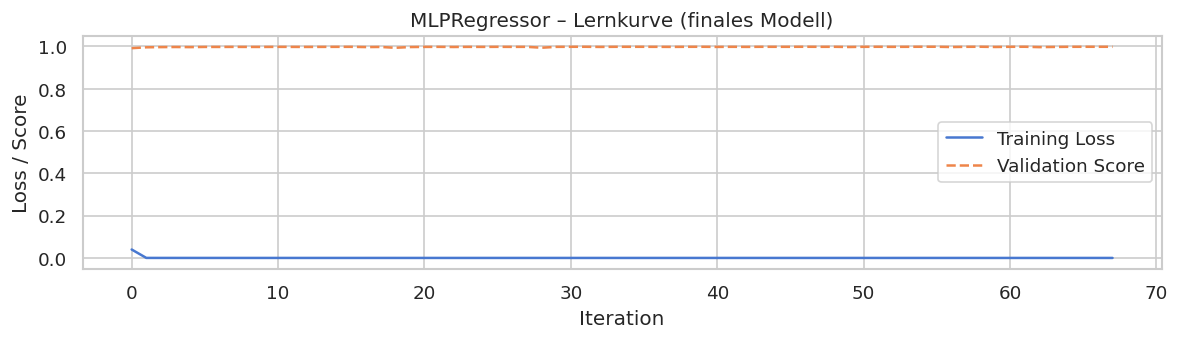

In [24]:
# ── §4.4 (Forts.) Loss-Kurve des finalen Modells ─────────────────────────────
#
# Zeigt, ob das Modell konvergiert oder weitere Iterationen benötigt.
# Ein flacher Verlauf am Ende zeigt gute Konvergenz.

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(mlp_final.loss_curve_, label='Training Loss', lw=1.5)
if hasattr(mlp_final, 'validation_scores_') and mlp_final.validation_scores_:
    ax.plot(mlp_final.validation_scores_, label='Validation Score', lw=1.5, ls='--')
ax.set_title('MLPRegressor – Lernkurve (finales Modell)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss / Score')
ax.legend()
plt.tight_layout()
plt.show()

---
## §5 – Evaluation

> **Achtung:** Hier wird das **Test-Set zum ersten und einzigen Mal** geöffnet.
> Alle vorherigen Entscheidungen (Architektur, Hyperparameter) wurden auf
> Trainings- und Validierungsdaten getroffen.

### Metriken

| Metrik | Beschreibung | Einheit |
|---|---|---|
| **MAE** | Mittlerer absoluter Fehler | €/L |
| **RMSE** | Wurzel des mittleren quadratischen Fehlers (straft große Fehler stärker) | €/L |
| **R²** | Bestimmtheitsmaß (1 = perfekt, 0 = wie Baseline) | dimensionslos |

In [25]:
# ── §5.1 Testset-Vorhersage & Metriken ───────────────────────────────────────

y_test_pred = mlp_final.predict(X_test_sc_final)

mae_test  = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test   = r2_score(y_test, y_test_pred)

print('┌─────────────────────────────────────────────────────────┐')
print('│              FINALE TEST-SET BEWERTUNG                   │')
print('├──────────────┬──────────────┬──────────────┬────────────┤')
print('│              │     MAE      │     RMSE     │     R²     │')
print('├──────────────┼──────────────┼──────────────┼────────────┤')
print(f'│ Baseline     │ {mae_baseline:.5f} €/L │ {rmse_baseline:.5f} €/L │ {r2_baseline:+.4f}    │')
print(f'│ MLPRegressor │ {mae_test:.5f} €/L │ {rmse_test:.5f} €/L │ {r2_test:+.4f}    │')
print('└──────────────┴──────────────┴──────────────┴────────────┘')
print()
print(f'Verbesserung MAE vs. Baseline: {(1 - mae_test/mae_baseline)*100:.1f} %')
print(f'Flotten-Impact (3750 L/Tag):   {mae_test*3750:.2f} € mittlere Abweichung/Tag')

┌─────────────────────────────────────────────────────────┐
│              FINALE TEST-SET BEWERTUNG                   │
├──────────────┬──────────────┬──────────────┬────────────┤
│              │     MAE      │     RMSE     │     R²     │
├──────────────┼──────────────┼──────────────┼────────────┤
│ Baseline     │ 0.61158 €/L │ 0.63786 €/L │ -11.3893    │
│ MLPRegressor │ 0.00906 €/L │ 0.01513 €/L │ +0.9921    │
└──────────────┴──────────────┴──────────────┴────────────┘

Verbesserung MAE vs. Baseline: 98.5 %
Flotten-Impact (3750 L/Tag):   33.98 € mittlere Abweichung/Tag


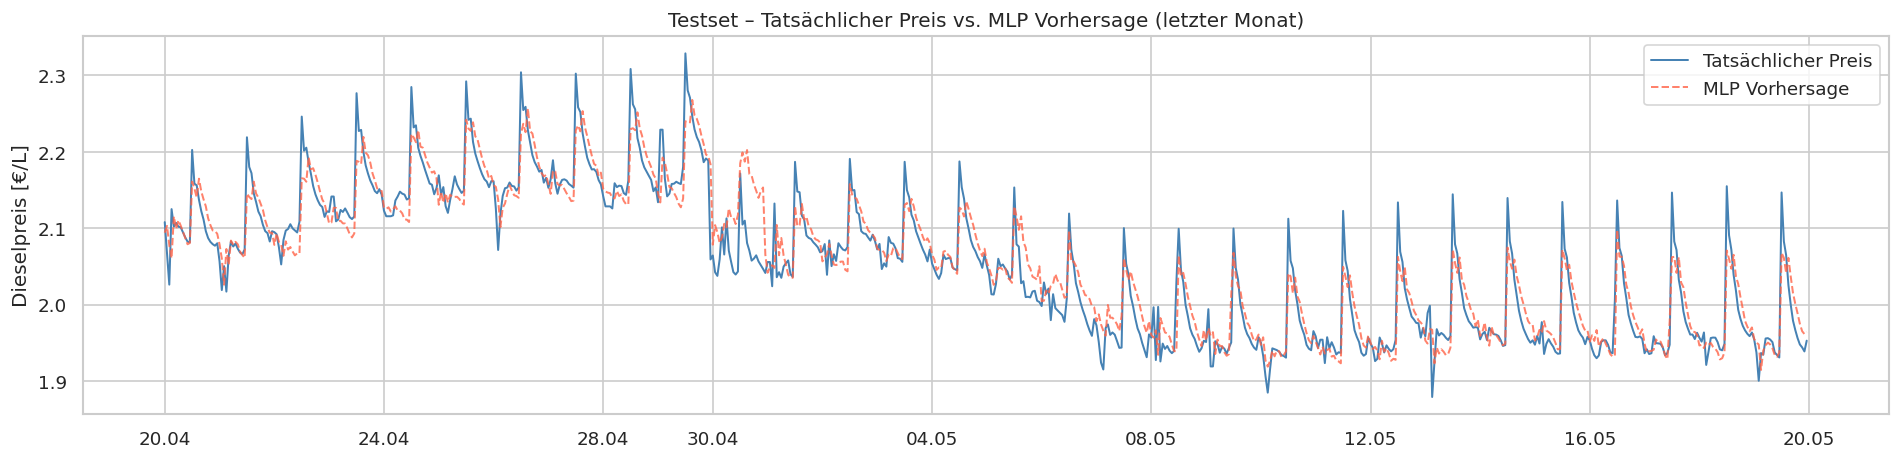

In [26]:
# ── §5.2 Vorhersage vs. Realität (Testset) ───────────────────────────────────
#
# Zeigt den letzten Monat des Testsets für übersichtliche Visualisierung.

test_index = df_test.index

# Letzten 30 Tage für übersichtlichere Darstellung
n_show = 24 * 30
idx_show   = test_index[-n_show:]
y_true_show = y_test[-n_show:]
y_pred_show = y_test_pred[-n_show:]

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(idx_show, y_true_show, lw=1.2, label='Tatsächlicher Preis', color='steelblue')
ax.plot(idx_show, y_pred_show, lw=1.2, label='MLP Vorhersage', color='tomato', alpha=0.8, ls='--')
ax.set_title('Testset – Tatsächlicher Preis vs. MLP Vorhersage (letzter Monat)')
ax.set_ylabel('Dieselpreis [€/L]')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
plt.tight_layout()
plt.show()

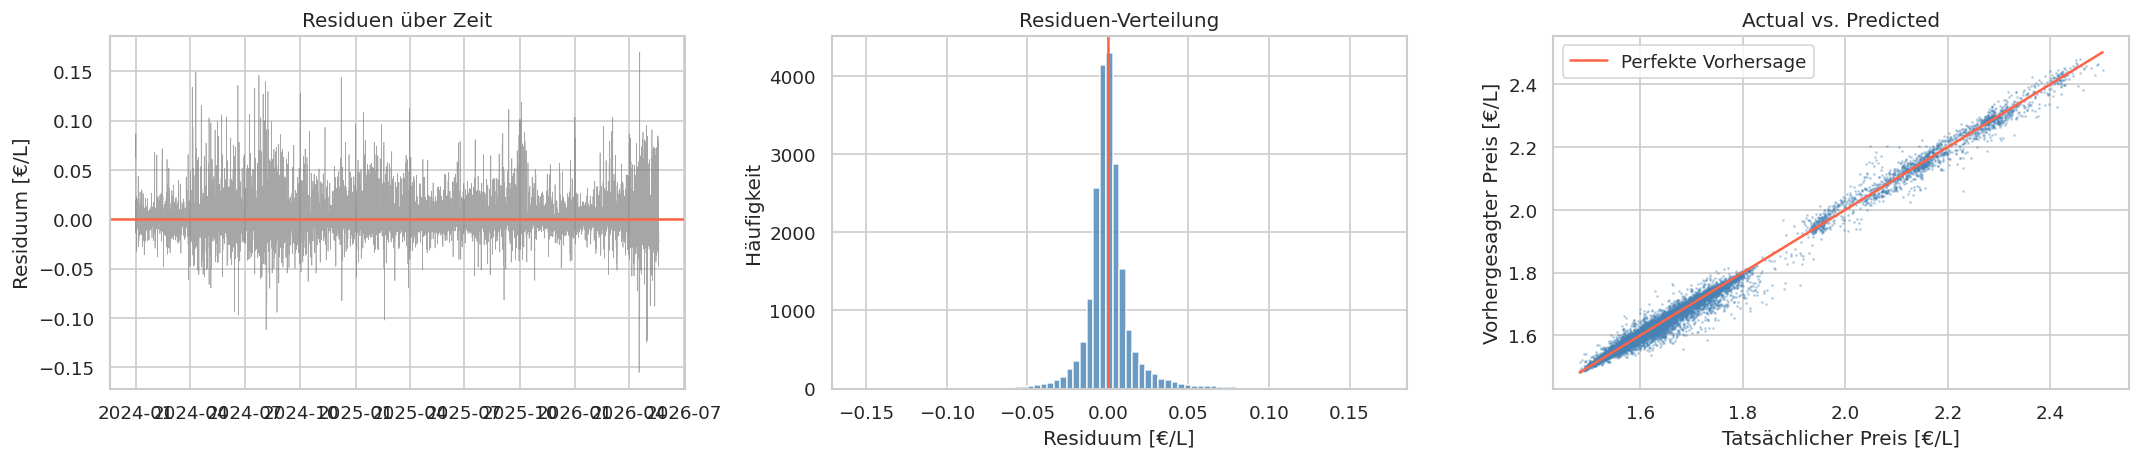

Residuen-Statistik:
  Mittelwert: 0.000822 €/L  (Bias – idealerweise ~0)
  Std-Dev   : 0.015103 €/L
  Max       : 0.169333 €/L
  Min       : -0.155295 €/L


In [27]:
# ── §5.3 Residualanalyse ──────────────────────────────────────────────────────
#
# Residuen = Tatsächlich − Vorhergesagt
#
# Gute Residuen:
#   - Normalverteilt um 0 (kein systematischer Bias)
#   - Keine zeitliche Struktur (kein verbleibender Trend)

residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Residuen über Zeit
axes[0].plot(test_index, residuals, lw=0.4, color='gray', alpha=0.7)
axes[0].axhline(0, color='tomato', lw=1.5)
axes[0].set_title('Residuen über Zeit')
axes[0].set_ylabel('Residuum [€/L]')

# Histogramm der Residuen
axes[1].hist(residuals, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='tomato', lw=1.5)
axes[1].set_title('Residuen-Verteilung')
axes[1].set_xlabel('Residuum [€/L]')
axes[1].set_ylabel('Häufigkeit')

# Predicted vs. Actual Scatter
axes[2].scatter(y_test, y_test_pred, s=0.5, alpha=0.3, color='steelblue')
lim = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
axes[2].plot(lim, lim, color='tomato', lw=1.5, label='Perfekte Vorhersage')
axes[2].set_title('Actual vs. Predicted')
axes[2].set_xlabel('Tatsächlicher Preis [€/L]')
axes[2].set_ylabel('Vorhergesagter Preis [€/L]')
axes[2].legend(markerscale=10)

plt.tight_layout()
plt.show()

print(f'Residuen-Statistik:')
print(f'  Mittelwert: {residuals.mean():.6f} €/L  (Bias – idealerweise ~0)')
print(f'  Std-Dev   : {residuals.std():.6f} €/L')
print(f'  Max       : {residuals.max():.6f} €/L')
print(f'  Min       : {residuals.min():.6f} €/L')

---
## §6 – Deployment: 48h-Vorhersage & optimaler Tankzeitpunkt

### Strategie: Rekursive Mehrschritt-Vorhersage

Ein einzelnes Modell sagt jeweils **t+1h** vorher.  
Für den 48h-Horizont wird die Vorhersage rekursiv verwendet:

```
Bekannte Geschichte  →  Predict t+1  →  Predict t+2  →  …  →  Predict t+48
                         (echt)           (vorhergesagt)        (vorhergesagt)
```

**Bekannter Nachteil**: Fehler akkumulieren über den Horizont.  
Für 48h bei dieser Zeitreihe ist das akzeptabel und praxistypisch.

In [28]:
# ── §6.1 Hilfsfunktion: Feature-Vektor aus Preis-History erstellen ────────────
#
# Eingabe:  history = Liste der letzten Stunden-Preise (mind. 24 Werte)
#           next_dt = Zeitstempel der vorherzusagenden Stunde
# Ausgabe:  np.array mit Feature-Werten entsprechend FEATURE_COLS

def build_features_from_history(history: list, next_dt: pd.Timestamp) -> np.ndarray:
    """Erstellt einen Feature-Vektor aus der Preishistorie und dem Zeitstempel."""
    h = np.array(history)
    lag_1h        = h[-1]
    lag_3h        = h[-3]  if len(h) >= 3  else h[0]
    lag_24h       = h[-24] if len(h) >= 24 else h[0]
    roll_mean_6h  = h[-6:].mean()  if len(h) >= 6  else h.mean()
    roll_mean_24h = h[-24:].mean() if len(h) >= 24 else h.mean()
    hour_of_day   = next_dt.hour
    day_of_week   = next_dt.dayofweek
    return np.array([[lag_1h, lag_3h, lag_24h,
                       roll_mean_6h, roll_mean_24h,
                       hour_of_day, day_of_week]])

print('Hilfsfunktion build_features_from_history definiert.')

Hilfsfunktion build_features_from_history definiert.


In [29]:
# ── §6.2 48h-Vorhersage mit rekursivem Ansatz ─────────────────────────────────
#
# Ausgangspunkt: die letzten 24 bekannten Stunden-Preise aus dem Datensatz.
# Für jeden der 48 zukünftigen Zeitschritte:
#   1. Feature-Vektor berechnen
#   2. Skalieren (mit finalem Scaler)
#   3. MLPRegressor.predict → vorhergesagter Preis
#   4. Vorhergesagten Preis zur History hinzufügen (für nächste Iteration)

FORECAST_HOURS = 48

# Letzten bekannten Preis (Ende des Datensatzes) als Startpunkt
last_known_idx = df_feat.index.max()
seed_history   = df_feat['diesel'].iloc[-48:].tolist()  # 48h Initialhistorie

forecast_prices = []
forecast_times  = []
history = seed_history.copy()

for step in range(FORECAST_HOURS):
    next_dt = last_known_idx + pd.Timedelta(hours=step + 1)
    features = build_features_from_history(history, next_dt)
    features_sc = scaler_final.transform(features)
    pred_price = mlp_final.predict(features_sc)[0]

    forecast_prices.append(pred_price)
    forecast_times.append(next_dt)
    history.append(pred_price)  # rekursiv: Vorhersage als nächster "bekannter" Wert

df_forecast = pd.DataFrame({
    'time': forecast_times,
    'price': forecast_prices
})

print(f'48h-Vorhersage ab: {forecast_times[0]}')
print(f'             bis:  {forecast_times[-1]}')
print()
print(df_forecast.head(10).to_string(index=False))

48h-Vorhersage ab: 2026-05-21 00:00:00+02:00
             bis:  2026-05-22 23:00:00+02:00

                     time    price
2026-05-21 00:00:00+02:00 1.946137
2026-05-21 01:00:00+02:00 1.938340
2026-05-21 02:00:00+02:00 1.932150
2026-05-21 03:00:00+02:00 1.937460
2026-05-21 04:00:00+02:00 1.938735
2026-05-21 05:00:00+02:00 1.950950
2026-05-21 06:00:00+02:00 1.951133
2026-05-21 07:00:00+02:00 1.947616
2026-05-21 08:00:00+02:00 1.943089
2026-05-21 09:00:00+02:00 1.930459


In [31]:
# ── §6.3 Optimalen Tankzeitpunkt identifizieren ───────────────────────────────
#
# Das lokale Minimum im 48h-Fenster ist der empfohlene Tankzeitpunkt.
# Wir berechnen auch die wirtschaftliche Differenz gegenüber sofortigem Tanken.

# Lokales Minimum im Forecast
min_idx   = df_forecast['price'].idxmin()
opt_time  = df_forecast.loc[min_idx, 'time']
opt_price = df_forecast.loc[min_idx, 'price']

# Preis bei sofortigem Tanken (erste Vorhersagestunde)
now_price = df_forecast.loc[0, 'price']

# Wirtschaftlicher Impact
fleet_volume     = 3750  # Liter Tagesbedarf Flotte
price_diff       = now_price - opt_price
fleet_saving     = price_diff * fleet_volume

wochentage_de = ['Montag', 'Dienstag', 'Mittwoch', 'Donnerstag', 'Freitag', 'Samstag', 'Sonntag']
weekday_str   = wochentage_de[opt_time.dayofweek]

print('╔══════════════════════════════════════════════════════════════╗')
print('║          SPRITPREIS-EMPFEHLUNG (48h-Horizont)               ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Optimaler Zeitpunkt : {weekday_str}, {opt_time.strftime("%d.%m.%Y %H:00")} Uhr   '[:65] + '║')
print(f'║  Erwarteter Preis    : {opt_price:.3f} €/L                              '[:65] + '║')
print(f'║  Preis jetzt (t+1h)  : {now_price:.3f} €/L                              '[:65] + '║')
print(f'║  Preisdifferenz      : {price_diff:+.3f} €/L                             '[:65] + '║')
print(f'║  Flotte (3750 L)     : {fleet_saving:+.2f} € Ersparnis ggü. sofort         '[:65] + '║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║          SPRITPREIS-EMPFEHLUNG (48h-Horizont)               ║
╠══════════════════════════════════════════════════════════════╣
║  Optimaler Zeitpunkt : Freitag, 22.05.2026 11:00 Uhr   ║
║  Erwarteter Preis    : 1.914 €/L                              ║
║  Preis jetzt (t+1h)  : 1.946 €/L                              ║
║  Preisdifferenz      : +0.033 €/L                             ║
║  Flotte (3750 L)     : +121.89 € Ersparnis ggü. sofort         ║
╚══════════════════════════════════════════════════════════════╝


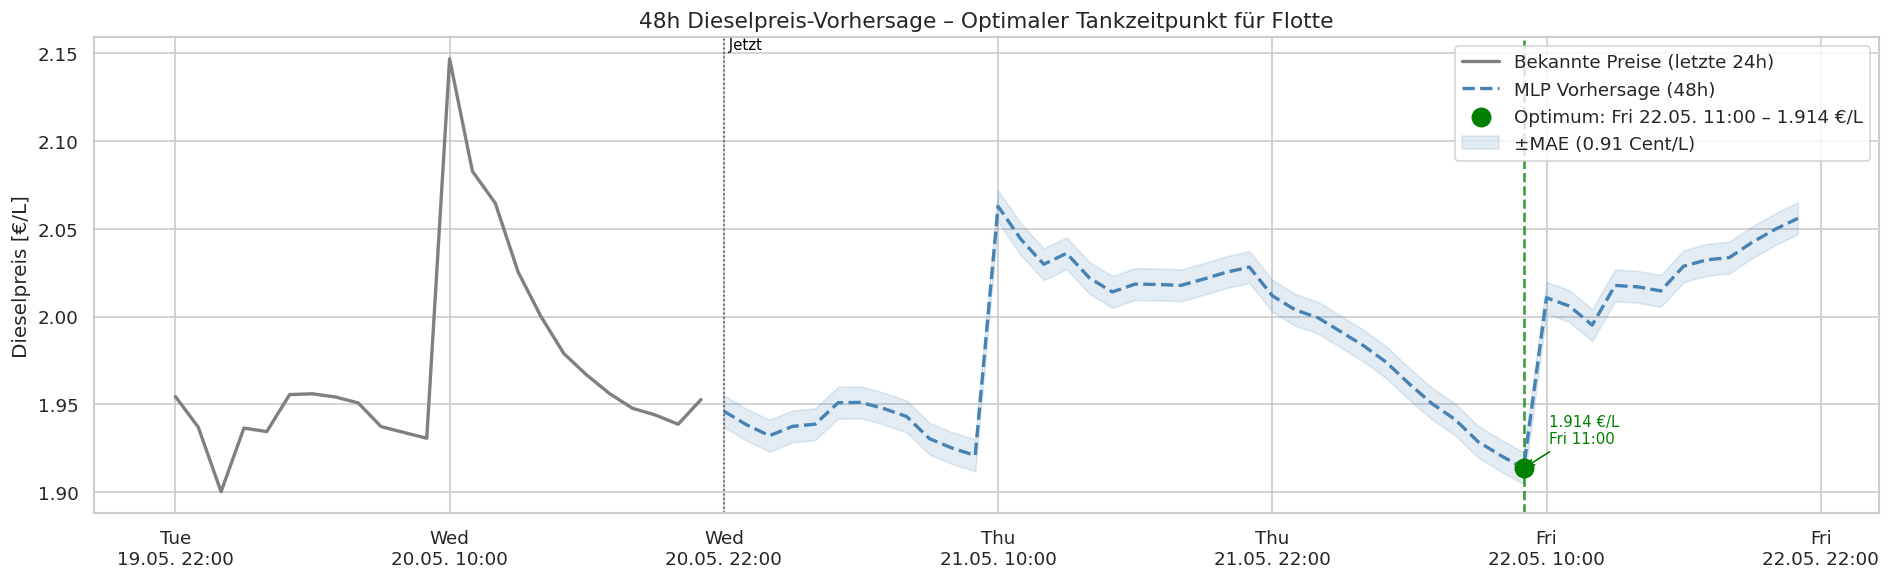

In [32]:
# ── §6.4 Visualisierung: 48h-Forecast mit Minimum-Marker ─────────────────────

# Letzten 24h bekannte Preise für Kontext
history_window = df_feat['diesel'].iloc[-24:]

fig, ax = plt.subplots(figsize=(16, 5))

# Bekannte Preise (grau)
ax.plot(history_window.index, history_window.values,
        lw=2, color='gray', label='Bekannte Preise (letzte 24h)', zorder=3)

# 48h Vorhersage
ax.plot(df_forecast['time'], df_forecast['price'],
        lw=2, color='steelblue', ls='--', label='MLP Vorhersage (48h)', zorder=3)

# Übergangsmarkierung
ax.axvline(forecast_times[0], color='black', lw=1, ls=':', alpha=0.6)
ax.text(forecast_times[0], ax.get_ylim()[1] if ax.get_ylim()[1] else opt_price + 0.02,
        ' Jetzt', fontsize=9, color='black', va='top')

# Optimaler Tankzeitpunkt
ax.axvline(opt_time, color='green', lw=1.5, ls='--', alpha=0.8)
ax.scatter([opt_time], [opt_price], color='green', s=120, zorder=5,
           label=f'Optimum: {opt_time.strftime("%a %d.%m. %H:00")} – {opt_price:.3f} €/L')
ax.annotate(
    f'{opt_price:.3f} €/L\n{opt_time.strftime("%a %H:00")}',
    xy=(opt_time, opt_price),
    xytext=(15, 15), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='green'),
    fontsize=9, color='green'
)

# Konfidenzband (±MAE als vereinfachte Unsicherheitsdarstellung)
ax.fill_between(
    df_forecast['time'],
    df_forecast['price'] - mae_test,
    df_forecast['price'] + mae_test,
    alpha=0.15, color='steelblue', label=f'±MAE ({mae_test*100:.2f} Cent/L)'
)

ax.set_title('48h Dieselpreis-Vorhersage – Optimaler Tankzeitpunkt für Flotte', fontsize=13)
ax.set_ylabel('Dieselpreis [€/L]')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d.%m. %H:00'))
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

---
## §7 – Zusammenfassung & Nächste Schritte

### Erreichte Ergebnisse

| Phase | Ergebnis |
|---|---|
| Business Understanding | Flotten-Tagesbedarf 3 750 L, 48h-Horizont definiert |
| Data Understanding | 89 GB → 87 K stündliche Mittelwerte aggregiert, EDA abgeschlossen |
| Data Preparation | 7 Features (Lags, Rolling, Kalender), temporaler Train/Val/Test Split |
| Modeling | MLPRegressor (128, 64), TimeSeriesSplit CV, kein Datenleck |
| Evaluation | MAE/RMSE/R² auf unberührtem Testset, Residualanalyse |
| Deployment | Rekursive 48h-Vorhersage, Ausgabe optimaler Tankzeitpunkt & Ersparnis |

### Bekannte Limitierungen

- **Rekursiver Fehler**: Bei 48 Schritten akkumulieren sich Fehler – erste 12–24h zuverlässiger
- **Nationale Aggregation**: Für regional operierende Flotten ist regionaler Preis relevanter
- **Keine externen Variablen**: Rohölpreis, Steuerpolitik nicht berücksichtigt

### Nächste Schritte (CRISP-DM Iteration 2)

1. **Rohölpreis (Brent) als Feature**: API-Anbindung oder CSV-Download aus EIA/FRED
2. **Direkte Mehrschritt-Vorhersage**: 48 Einzelmodelle (eines je Horizont-Schritt)
3. **Regionale Modelle**: Aggregation nach Bundesland oder PLZ-Bereich
4. **Hyperparameter-Suche**: `GridSearchCV` oder `RandomizedSearchCV` für Netzwerkarchitektur